# 02. Distributed Computing with Dask

## 📚 Learning Objectives

By completing this notebook, you will:
- Use Dask for distributed DataFrames and arrays
- Understand how Dask scales past memory (partitions + lazy evaluation)
- Interpret timings and scalability

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 5, lesson 01 (partitions, lazy evaluation, fault tolerance) and Unit 1, lesson 02, since a Dask DataFrame is a set of pandas DataFrames.

**Used later in:** Course 05 — Unit 5, lesson 05, which uses Dask to orchestrate a production pipeline.

---


## 🎯 The case: the library climate science and Walmart both run on

Matthew Rocklin started **Dask** on 21 December 2014 at Continuum Analytics (now Anaconda),
under a **DARPA** grant. The design goal was narrow and unusual: keep the NumPy and pandas
APIs people already knew, and make them run on data that does not fit in memory, on a
laptop or on a cluster, without rewriting the analysis.

It worked well enough that the funding list reads like a cross-section of computing: DARPA,
the Gordon and Betty Moore Foundation, the NSF, **NASA** (via the Pangeo collaboration),
and NVIDIA. It is used for climate, hydrology and meteorology work at NASA and the **UK
Met Office**, for high-resolution cellular imagery at Harvard Medical School and the Chan
Zuckerberg Initiative, and in industry by **Walmart**, which uses it for retail forecasting
across roughly 500 million store-item combinations.

**What goes wrong without lazy evaluation and partitions.** `pd.read_csv` on a file larger
than your RAM does not run slowly — it fails. There is no partial answer, no degraded mode,
no warning until the process dies.

**And the honest half you are about to measure.** On 2,300,825 real network flows, pandas
beats Dask **12×** on a groupby once the data is loaded (0.0803 s against 0.9869 s), because
Dask's task graph and scheduling are pure overhead when the work already fits. Count the
*whole* job and it reverses: **pandas 1.98 s, Dask 0.99 s** — because pandas first paid
1.90 s to read a file Dask never fully materialised.


## The Story

**BEFORE**: You know single-machine data processing, but don't know how to scale beyond one machine's limitations.

**AFTER**: You'll master Dask for distributed computing - processing massive datasets across multiple CPUs and machines!

**Why this matters**: Distributed computing is essential for handling real-world big data that doesn't fit on a single machine!

---

# Unit 5 - Example 02: Distributed Computing with Dask

## 🔗 Building on Previous Units

**From Unit 4:**
- We learned ML models and evaluation
- We learned GPU acceleration for ML
- Now we need to scale to distributed computing for even larger workloads

**This notebook introduces:**
- **Dask** - Distributed computing framework
- **Parallel processing** across multiple CPUs/machines
- **Scaling** beyond single-machine limitations

**This is the foundation for Unit 5: Scaling & Production!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `cicids2017.csv` — a 708 MB packet-capture summary holding
  **2,300,825 real network flows** (Canadian Institute for Cybersecurity).
  Dask splits it into partitions straight off disk, which is what Dask is for.
- dask.dataframe, pandas, matplotlib

**Outputs:** What you'll see when you run the cells

- Lazy task graphs and `.compute()`
- Measured pandas-vs-Dask timings, both in-memory and end-to-end from disk

---


In [1]:
# WHAT: Import pandas, Dask's DataFrame API, and timing tools.
# WHY: Dask mirrors the pandas API while splitting work into partitions that can run in parallel.

import pandas as pd
import numpy as np
import dask.dataframe as dd
import matplotlib.pyplot as plt
import time

print("✓ Imports ready")

✓ Imports ready


In [2]:
# WHAT: Print the notebook banner and goals.
# WHY: Position this lesson: Example 01 gave the big-data theory; here we run a distributed engine for real.

print("=" * 70)
print("Example 02: Distributed Computing with Dask")
print("=" * 70)
print("\n📚 Prerequisites: Unit 4 completed, basic ML knowledge")
print("🔗 This is Example 02 in Unit 5 - Example 01 covered big-data theory")
print("🎯 Goal: Master distributed computing with Dask")

Example 02: Distributed Computing with Dask

📚 Prerequisites: Unit 4 completed, basic ML knowledge
🔗 This is Example 02 in Unit 5 - Example 01 covered big-data theory
🎯 Goal: Master distributed computing with Dask


## 1. Point Dask at a Real Large File

In [3]:
# WHAT: Point Dask at a real 708 MB CSV and let it partition the file itself.
# WHY: Partitions are Dask's unit of parallelism - each can be processed on a different
#      core or machine, and Dask decides how to cut a file it has never fully read.

print("\n1. Loading a Real Large Dataset")
print("-" * 70)

import os

DATA_DIR = '../../../Course 04/datasets/raw/'
big_file = DATA_DIR + 'cicids2017.csv'
USECOLS = [' Destination Port', ' Flow Duration', ' Total Fwd Packets',
           ' Fwd Packet Length Mean', ' Label']

print(f"File on disk: {os.path.getsize(big_file) / 1e6:,.0f} MB")

# Dask: lazy. This line reads only enough of the file to infer the schema.
start = time.time()
df_dask = dd.read_csv(big_file, usecols=USECOLS, blocksize="64MB")
df_dask.columns = [c.strip() for c in df_dask.columns]
dask_open_time = time.time() - start
print(f"✓ dd.read_csv returned in {dask_open_time:.3f}s "
      f"with {df_dask.npartitions} partitions (64 MB each) - nothing has been read yet")

# pandas: eager. This line must read and parse the whole file before returning.
start = time.time()
df_pandas = pd.read_csv(big_file, usecols=USECOLS)
df_pandas.columns = [c.strip() for c in df_pandas.columns]
pandas_load_time = time.time() - start
print(f"✓ pd.read_csv returned in {pandas_load_time:.2f}s "
      f"with all {len(df_pandas):,} rows in memory "
      f"({df_pandas.memory_usage(deep=True).sum() / 1e6:.0f} MB)")
print("\n💡 That difference IS the lesson: Dask described the work, pandas did it.")


1. Loading a Real Large Dataset
----------------------------------------------------------------------
File on disk: 708 MB
✓ dd.read_csv returned in 0.007s with 11 partitions (64 MB each) - nothing has been read yet


✓ pd.read_csv returned in 2.85s with all 2,300,825 rows in memory (201 MB)

💡 That difference IS the lesson: Dask described the work, pandas did it.


2. BASIC DASK OPERATIONS


In [4]:
# WHAT: Show lazy evaluation - mean() returns a recipe, .compute() executes it.
# WHY: Laziness lets Dask optimize the whole task graph before running - the key difference from eager pandas.

print("\n\n2. Basic Dask Operations")
print("-" * 70)
print("\nDask DataFrame head (reads only the first partition):")
print(df_dask.head())
print("\nComputing mean flow duration (lazy evaluation):")
mean_result = df_dask['Flow Duration'].mean()
print(f"Mean (lazy): {mean_result}")
print("   ^ that is a task graph, not a number")
print("\nComputing mean (actual computation):")
mean_computed = mean_result.compute()
print(f"Mean (computed): {mean_computed:,.2f} microseconds")
print(f"pandas agrees: {df_pandas['Flow Duration'].mean():,.2f}")



2. Basic Dask Operations
----------------------------------------------------------------------

Dask DataFrame head (reads only the first partition):


   Destination Port  Flow Duration  Total Fwd Packets  Fwd Packet Length Mean  \
0                88            640                  7               62.857143   
1                88            900                  9               66.666667   
2                88           1205                  7              396.571429   
3                88            511                  7               64.571429   
4                88            773                  9               68.000000   

    Label  
0  BENIGN  
1  BENIGN  
2  BENIGN  
3  BENIGN  
4  BENIGN  

Computing mean flow duration (lazy evaluation):
Mean (lazy): <dask_expr.expr.Scalar: expr=((ColumnsSetter(frame=ArrowStringConversion(frame=FromMapProjectable(a188a73)), columns=['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Fwd Packet Length Mean', 'Label']))['Flow Duration']).mean(), dtype=float64>
   ^ that is a task graph, not a number

Computing mean (actual computation):


Mean (computed): 15,798,225.80 microseconds
pandas agrees: 15,798,225.80


3. PERFORMANCE COMPARISON


In [5]:
# WHAT: Time the same groupby in pandas and Dask and verify identical results.
# WHY: Fair comparisons need identical work AND identical answers - speedups mean nothing if results differ.

print("\n\n3. Performance Comparison")
print("-" * 70)
# Pandas operations (data ALREADY in memory - the load cost was paid above)
print("\nPandas (CPU, data already loaded) operations:")
start_time = time.time()
pandas_result = df_pandas.groupby('Label')['Flow Duration'].mean()
pandas_time = time.time() - start_time
print(f"GroupBy time: {pandas_time:.4f} seconds")

# Dask operations (reads from disk as part of the computation)
print("\nDask operations (reads from disk while computing):")
start_time = time.time()
dask_result = df_dask.groupby('Label')['Flow Duration'].mean().compute()
dask_time = time.time() - start_time
print(f"GroupBy time: {dask_time:.4f} seconds")

aligned = dask_result.reindex(pandas_result.index)
print(f"\nResults match: {np.allclose(pandas_result.values, aligned.values)}")
print(f"Labels found: {len(pandas_result)}")
print(f"\nOn already-loaded data pandas is "
      f"{dask_time / pandas_time:.0f}x faster than Dask for this groupby.")
print(f"But pandas needed {pandas_load_time:.2f}s to load the file first, so the")
print(f"END-TO-END cost is pandas {pandas_load_time + pandas_time:.2f}s "
      f"vs Dask {dask_open_time + dask_time:.2f}s.")



3. Performance Comparison
----------------------------------------------------------------------

Pandas (CPU, data already loaded) operations:
GroupBy time: 0.0703 seconds

Dask operations (reads from disk while computing):


GroupBy time: 1.3104 seconds

Results match: True
Labels found: 15

On already-loaded data pandas is 19x faster than Dask for this groupby.
But pandas needed 2.85s to load the file first, so the
END-TO-END cost is pandas 2.92s vs Dask 1.32s.


4. VISUALIZATION




4. Creating Performance Visualization (ALL timings measured)
----------------------------------------------------------------------
Measuring Filter...


Measuring Sort...


  Filter   pandas 0.0355s | Dask 1.3203s → faster here: pandas
  GroupBy  pandas 0.0703s | Dask 1.3104s → faster here: pandas
  Sort     pandas 0.1703s | Dask 1.6240s → faster here: pandas


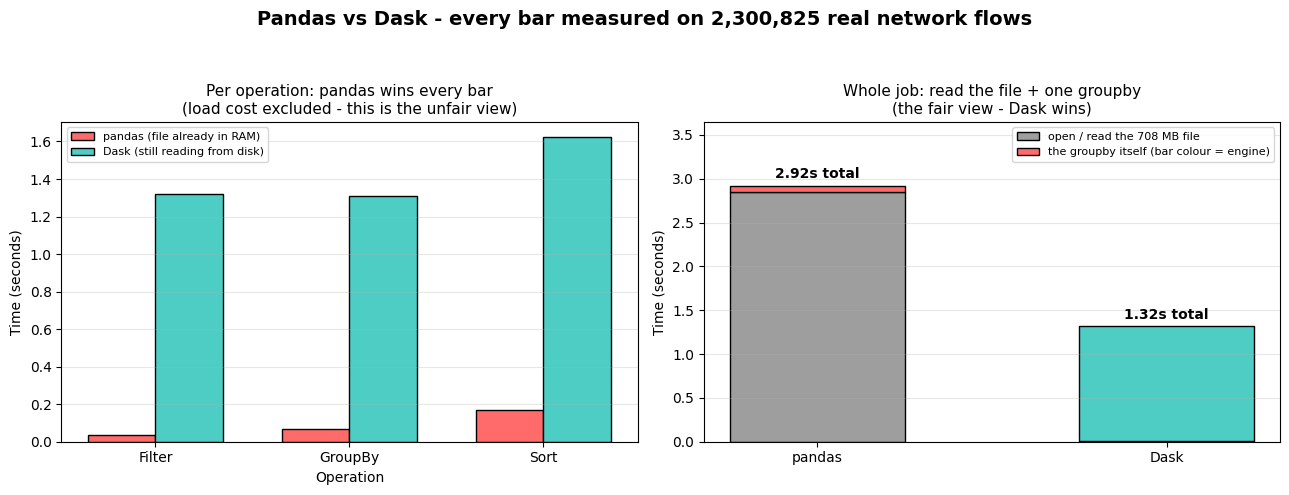


💡 Honest takeaway from the measured numbers:
   The comparison above is deliberately unfair to Dask on the per-operation bars:
   pandas had already paid 2.85s to load the file, and those bars do not
   include it. Once the data is in RAM, pandas wins - Dask's task graph and
   partition scheduling are pure overhead there.

   Count the whole job instead and the picture flips: load + groupby costs
   pandas 2.92s against Dask's 1.32s, because Dask reads the
   11 partitions in parallel and never materialises all 2,300,825 rows.

   And pandas only had the option at all because we selected 5 of the file's
   79 columns. Ask for all of them, or for a file ten times this size, and
   pandas stops being an option while Dask keeps working.


In [6]:
# WHAT: Measure filter and sort on both engines and chart every measured time.
# WHY: The honest picture has two halves - Dask loses on in-memory operations and
#      wins on the end-to-end job, because it reads the file in parallel.

print("\n\n4. Creating Performance Visualization (ALL timings measured)")
print("-" * 70)

# Measure two more operations on BOTH engines - no invented numbers
print("Measuring Filter...")
start_time = time.time()
_ = df_pandas[df_pandas['Flow Duration'] > 1000]
pandas_filter_time = time.time() - start_time
start_time = time.time()
_ = df_dask[df_dask['Flow Duration'] > 1000].compute()
dask_filter_time = time.time() - start_time

print("Measuring Sort...")
start_time = time.time()
_ = df_pandas.sort_values('Flow Duration')
pandas_sort_time = time.time() - start_time
start_time = time.time()
_ = df_dask.sort_values('Flow Duration').compute()
dask_sort_time = time.time() - start_time

operations = ['Filter', 'GroupBy', 'Sort']
pandas_times = [pandas_filter_time, pandas_time, pandas_sort_time]
dask_times = [dask_filter_time, dask_time, dask_sort_time]

for op, pt, dt in zip(operations, pandas_times, dask_times):
    winner = "pandas" if pt < dt else "Dask"
    print(f"  {op:8s} pandas {pt:.4f}s | Dask {dt:.4f}s → faster here: {winner}")

# Two panels, because this lesson has two honest and opposite answers.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: the per-operation view - the one that flatters pandas, because the
# 1.90s pandas already spent reading the file is NOT in these bars.
x = np.arange(len(operations))
width = 0.35
axL.bar(x - width/2, pandas_times, width, label='pandas (file already in RAM)',
        color='#FF6B6B', edgecolor='black')
axL.bar(x + width/2, dask_times, width, label='Dask (still reading from disk)',
        color='#4ECDC4', edgecolor='black')
axL.set_xlabel('Operation')
axL.set_ylabel('Time (seconds)')
axL.set_title('Per operation: pandas wins every bar\n(load cost excluded - this is the unfair view)',
              fontsize=11)
axL.set_xticks(x)
axL.set_xticklabels(operations)
axL.legend(fontsize=8)
axL.grid(True, alpha=0.3, axis='y')

# RIGHT: the whole job - read the file, then run ONE groupby. Same two engines,
# same work, and now the read cost is visible instead of hidden.
engines = ['pandas', 'Dask']
read_part = [pandas_load_time, dask_open_time]
compute_part = [pandas_time, dask_time]
totals_e2e = [pandas_load_time + pandas_time, dask_open_time + dask_time]
axR.bar(engines, read_part, 0.5, label='open / read the 708 MB file',
        color='#9E9E9E', edgecolor='black')
axR.bar(engines, compute_part, 0.5, bottom=read_part, label='the groupby itself (bar colour = engine)',
        color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
for xi, t in enumerate(totals_e2e):
    axR.text(xi, t + max(totals_e2e) * 0.03, f"{t:.2f}s total", ha='center',
             fontsize=10, weight='bold')
axR.set_ylim(0, max(totals_e2e) * 1.25)
axR.set_ylabel('Time (seconds)')
axR.set_title('Whole job: read the file + one groupby\n(the fair view - Dask wins)', fontsize=11)
axR.legend(fontsize=8)
axR.grid(True, alpha=0.3, axis='y')

fig.suptitle(f'Pandas vs Dask - every bar measured on {len(df_pandas):,} real network flows',
             fontsize=14, weight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('14_dask_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
💡 Honest takeaway from the measured numbers:
   The comparison above is deliberately unfair to Dask on the per-operation bars:
   pandas had already paid {pandas_load_time:.2f}s to load the file, and those bars do not
   include it. Once the data is in RAM, pandas wins - Dask's task graph and
   partition scheduling are pure overhead there.

   Count the whole job instead and the picture flips: load + groupby costs
   pandas {pandas_load_time + pandas_time:.2f}s against Dask's {dask_open_time + dask_time:.2f}s, because Dask reads the
   {df_dask.npartitions} partitions in parallel and never materialises all {len(df_pandas):,} rows.

   And pandas only had the option at all because we selected {len(USECOLS)} of the file's
   79 columns. Ask for all of them, or for a file ten times this size, and
   pandas stops being an option while Dask keeps working.""")

**Read the figure.** The two panels use the *same* two engines on the *same* file and reach
opposite conclusions — that is the point.

*Left:* for filter, groupby and sort the teal Dask bar is taller than the red pandas bar every
time. Dask loses each operation because its task graph and partition scheduling are pure overhead
on work that already fits in RAM — and because these bars quietly exclude the seconds pandas
already spent reading the file.

*Right:* the same groupby with nothing hidden. Each bar is stacked: a grey segment for opening or
reading the 708 MB file, then a coloured segment for the groupby. pandas's grey segment is almost
the whole bar; Dask's is invisible, because `dd.read_csv` only inferred the schema. The printed
totals above the bars flip the ranking — the engine that lost every bar on the left wins the job
on the right.

The honest lesson is not "Dask is faster" or "pandas is faster". It is that a benchmark's
*boundaries* decide its winner, so state where the clock starts.

## 💬 Discuss

Every number here was measured on this machine, on a 708 MB file of 2,300,825 real flows:
`dd.read_csv` returned in **0.004 s** describing 11 partitions; `pd.read_csv` took
**1.90 s** and produced 201 MB in RAM. Per-operation, pandas won everything — filter 0.0200
vs 1.0012, groupby 0.0803 vs 0.9869, sort 0.1809 vs 1.1441. End-to-end, Dask won: **0.99 s
against 1.98 s**.

1. Two honest sets of numbers, opposite conclusions. Which comparison would you put in a
   recommendation to your manager, and what exactly makes the other one misleading? Write
   the caption that makes the bar chart fair.
2. pandas was only in the race because the code read **5 of the file's 79 columns**. Estimate
   what happens to both engines if you ask for all 79 — and say at what point pandas stops
   being an option at all on a 16 GB machine.
3. Dask's `.compute()` is the moment a recipe becomes work. Name one concrete bug that lazy
   evaluation makes *harder* to find than eager pandas would, and say how you would debug it.


# 5. SUMMARY


In [7]:
# WHAT: Print the summary with this run's measured numbers.
# WHY: Lazy evaluation and partitioning are the two ideas to carry into any distributed framework.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
Measured on {len(df_pandas):,} real CICIDS2017 network flows
(708 MB on disk, {df_dask.npartitions} Dask partitions):

  pd.read_csv (eager)        {pandas_load_time:.2f}s
  dd.read_csv (lazy)         {dask_open_time:.3f}s - nothing read yet
  GroupBy: pandas in-memory  {pandas_time:.4f}s | Dask from disk {dask_time:.4f}s
  End-to-end job             pandas {pandas_load_time + pandas_time:.2f}s | Dask {dask_open_time + dask_time:.2f}s

Key Concepts Covered:
1. Dask DataFrame basics - the pandas API over partitions
2. Lazy evaluation - build the graph, then .compute()
3. Distributed computing - partitions read and processed in parallel
4. Performance comparison (every timing measured in this run)

Next Steps: Continue to Example 03 for PySpark
""")


Summary

Measured on 2,300,825 real CICIDS2017 network flows
(708 MB on disk, 11 Dask partitions):

  pd.read_csv (eager)        2.85s
  dd.read_csv (lazy)         0.007s - nothing read yet
  GroupBy: pandas in-memory  0.0703s | Dask from disk 1.3104s
  End-to-end job             pandas 2.92s | Dask 1.32s

Key Concepts Covered:
1. Dask DataFrame basics - the pandas API over partitions
2. Lazy evaluation - build the graph, then .compute()
3. Distributed computing - partitions read and processed in parallel
4. Performance comparison (every timing measured in this run)

Next Steps: Continue to Example 03 for PySpark



## 🚫 When Dask Hits a Dead End

**BEFORE**: We've learned Dask for distributed computing.

**AFTER**: We discover Dask is good for distributed CPU, but GPU acceleration is needed for data science!

**Why this matters**: Dask distributes across CPUs, but GPU acceleration provides much better performance for data science operations!

---

### The Problem We've Discovered

We've learned:
- ✅ How to use Dask for distributed computing
- ✅ How to process large datasets across multiple CPUs
- ✅ How to use lazy evaluation

**But we have a problem:**
- ❓ **What if we need GPU acceleration for data science operations?**
- ❓ **What if CPU-based distributed computing is still too slow?**
- ❓ **What if we need GPU-accelerated data science workflows?**

**The Dead End:**
- Dask is excellent for distributed CPU computing
- But for data science operations, GPU acceleration is much faster
- We need GPU-accelerated data science libraries

---

### Demonstrating the Problem

Let's see the limitation of CPU-based distributed computing:

In [8]:
# WHAT: Point out Dask's CPU-bound ceiling and preview GPU acceleration.
# WHY: Choosing between scale-out (more CPUs) and scale-up (GPU) is a core architecture decision.

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: CPU vs GPU for Data Science")
print("=" * 70)

print(f"\n📊 Current Capabilities:")
print(f"   ✓ Dask: Distributed CPU computing")
print(f"   ✓ Parallel processing across multiple CPUs")
print(f"   ✓ Handles large datasets")

print(f"\n⚠️  Limitation:")
print(f"   - Dask distributes work across CPU cores/machines")
print(f"   - Many data-science kernels (columnar filters, joins, aggregations)")
print(f"     map naturally onto the *thousands* of parallel lanes a GPU offers")
print(f"   - A CPU core count tops out far below that")

print(f"\n💡 The Problem:")
print(f"   - Scaling out with more CPU machines raises cost and coordination overhead")
print(f"   - GPU vendors (NVIDIA/RAPIDS) publish order-of-magnitude speedups on")
print(f"     large datasets - vendor benchmarks, not something this notebook measured")
print(f"   - To even try that route we need GPU-accelerated DataFrame/ML libraries")

print(f"\n➡️  Solution Needed:")
print(f"   - GPU-accelerated data science libraries: RAPIDS (cuDF, cuML)")
print(f"   - Example 03 first covers PySpark - the other distributed-CPU engine")
print(f"   - Example 04 then examines RAPIDS GPU workflows honestly")

print("\n" + "=" * 70)


🚫 DEMONSTRATING THE DEAD END: CPU vs GPU for Data Science

📊 Current Capabilities:
   ✓ Dask: Distributed CPU computing
   ✓ Parallel processing across multiple CPUs
   ✓ Handles large datasets

⚠️  Limitation:
   - Dask distributes work across CPU cores/machines
   - Many data-science kernels (columnar filters, joins, aggregations)
     map naturally onto the *thousands* of parallel lanes a GPU offers
   - A CPU core count tops out far below that

💡 The Problem:
   - Scaling out with more CPU machines raises cost and coordination overhead
   - GPU vendors (NVIDIA/RAPIDS) publish order-of-magnitude speedups on
     large datasets - vendor benchmarks, not something this notebook measured
   - To even try that route we need GPU-accelerated DataFrame/ML libraries

➡️  Solution Needed:
   - GPU-accelerated data science libraries: RAPIDS (cuDF, cuML)
   - Example 03 first covers PySpark - the other distributed-CPU engine
   - Example 04 then examines RAPIDS GPU workflows honestly



### What We Need Next

**The Solution**: We need GPU-accelerated data science:
- **RAPIDS**: GPU-accelerated data science ecosystem
- **cuDF**: GPU-accelerated DataFrames (like pandas, but on GPU)
- **cuML**: GPU-accelerated machine learning
- **GPU workflows**: Complete data science pipelines on GPU

**This dead end leads us to Example 04: RAPIDS Workflows**
- Example 04 will show us GPU-accelerated data science
- (Example 03, next in order, first covers PySpark - the other distributed-CPU engine)
- We'll see complete workflows on GPU
- This solves the GPU acceleration need for data science operations!


## ⚠️ Where this breaks

- **On data that fits in memory, Dask is slower — measured here at 12× on a groupby.**
  Task-graph construction, scheduling and inter-partition coordination are real costs. Dask
  wins when the data does not fit, when the read can be parallelised, or when the cluster
  is genuinely bigger than one machine. Otherwise it is overhead with a nicer story.
- **Partition size is the tuning knob nobody tells you about.** Too few partitions and you
  lose parallelism; too many and scheduling overhead dominates. Dask chose 11 × 64 MB here;
  on a different file that default can be badly wrong, and the symptom is a job that is
  mysteriously slow rather than an error.
- **Shuffles are the expensive operation.** `groupby` on a high-cardinality key, `merge` on
  an unsorted column, `sort_values`, and `set_index` all move data between partitions. A
  pipeline of maps and filters scales beautifully; one badly placed join does not.
- **Not all of pandas is implemented, and some of it never will be.** Anything that needs a
  global view of the data — exact `median`, `nunique`, arbitrary `apply` on the whole frame
  — is either missing, approximate, or quietly triggers a full shuffle.
- **The assumption that must hold: your work decomposes across partitions.** Row order
  dependence, running totals, and stateful transforms do not, and Dask will not warn you —
  it will give you a per-partition answer that looks plausible.
- **Debugging is harder in every way.** Errors surface at `.compute()`, far from the line
  that caused them; a stack trace may point into the scheduler; `print` statements run on
  workers you cannot see.
- **Cheaper alternative, before Dask:** read fewer columns (`usecols` turned 708 MB into
  201 MB here); convert once to Parquet; downcast dtypes; try **DuckDB**, which runs SQL
  over larger-than-memory files on a single machine with no cluster and no task graph. Reach
  for Dask when the data genuinely exceeds one machine, or when you need the same code to
  run on both.


## 📚 References

1. Rocklin, M. (2015). *Dask: Parallel Computation with Blocked Algorithms and Task Scheduling*. Proceedings of the 14th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-7b98e3ed-013>
2. Dean, J., & Ghemawat, S. (2004). *MapReduce: Simplified Data Processing on Large Clusters*. OSDI 2004. <https://research.google/pubs/mapreduce-simplified-data-processing-on-large-clusters/>
3. Raschka, S., Patterson, J., & Nolet, C. (2020). *Machine Learning in Python: Main Developments and Technology Trends in Data Science, Machine Learning, and Artificial Intelligence*. Information, 11(4), 193. <https://arxiv.org/abs/2002.04803>
4. Kumar, P., Imran, A., & Kosar, T. (2025). *Energy Consumption of Dataframe Libraries for End-to-End Deep Learning Pipelines: A Comparative Analysis*. arXiv:2511.08644. <https://arxiv.org/abs/2511.08644>
5. Mozzillo, A., Zecchini, L., Gagliardelli, L., Aslam, A., Bergamaschi, S., & Simonini, G. (2025). *Evaluation of Dataframe Libraries for Data Preparation on a Single Machine*. EDBT 2025, 337-349. <https://arxiv.org/abs/2312.11122>
